# Theta_reg analysis — all events pooled

Only `Theta_reg` (never `theta_t`/MGD). Every seed's fit is loaded, averaged (mean +- std across seeds), and used to evaluate real data. Companion notebook: `turb_theta_reg_rare_typical.ipynb` (same setup, split by rare/typical). Superseded, more exploratory version: `turb_theta_scaling_OLD.ipynb`.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys, os, re, math
from types import SimpleNamespace

root = Path().resolve()
sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import *
from filters_bank import *
from potentials import *
from ortho_wavelet import *
from check_potentials import *  # theta_column_map, decode_mod2_stq, etc.

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', root)

device: cuda | /libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence


In [2]:
import os

# LOCAL vs JEAN ZAY -- load_turbulence_1d()'s default path in data_loader.py
# is Jean-Zay-only (/lustre/...). Flip to "jean_zay" there instead of editing this.
# PHI_CHUNK_SIZE batches phi(x)/grad(x) evaluation over the sample dim -- evaluating
# Scattering_Fourth_Order_Mod2_{Real,Imag}_Q1 on the full n1=5000 batch at once
# materializes a ~5.9GB intermediate BEFORE any reduction (measured directly:
# DefaultCPUAllocator asked for exactly 5898240000 bytes) -- chunking avoids it
# with no change to the result. Jean Zay has enough RAM/GPU memory to skip it.
RUN_LOCATION = "local"   # "local" or "jean_zay"

if RUN_LOCATION == "local" and torch.cuda.is_available():
    # A fixed chunk_size=500 assumes a GPU mostly to ourselves. On a GPU shared with
    # other processes (measured here: a co-tenant job holding ~19.5/22GB, leaving as
    # little as ~40MB free) that assumption breaks and 500 alone can still OOM. The
    # ~5.9GB/5000-sample intermediate above scales to ~1.2MiB/sample, so size the
    # chunk from what's ACTUALLY free right now (measured before potentials/data are
    # loaded, so this slightly overestimates later headroom -- the 2x margin covers
    # that plus the other job's usage not being static).
    free_bytes, _ = torch.cuda.mem_get_info()
    BYTES_PER_SAMPLE = 1.2 * 1024 ** 2
    PHI_CHUNK_SIZE = max(1, int(free_bytes / BYTES_PER_SAMPLE / 2))
    print(f"GPU free memory: {free_bytes / 1e6:.0f}MB -> PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE}")
else:
    PHI_CHUNK_SIZE = 500 if RUN_LOCATION == "local" else None

if RUN_LOCATION == "local":
    local_turbulence_path = (root / "../data/data_files/turbulence_1d_period.pt").resolve()
    if local_turbulence_path.exists():
        os.environ["TURBULENCE_1D_DATA_PATH"] = str(local_turbulence_path)
    else:
        print(f"WARNING: {local_turbulence_path} not found -- load_turbulence_1d() "
              f"will fall back to its Jean Zay default path and fail locally.")
print(f"RUN_LOCATION = {RUN_LOCATION!r}, PHI_CHUNK_SIZE = {PHI_CHUNK_SIZE!r}")

GPU free memory: 2434MB -> PHI_CHUNK_SIZE = 967
RUN_LOCATION = 'local', PHI_CHUNK_SIZE = 967


In [3]:
J, Q, M = 8, 3, 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
regularization = 1e-2

W = DefineWavelet('Db', m=3, device=device)
Data = load_turbulence_1d().to(device)
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)
scales = 2   # M == 256
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])
print('Data shape:', Data.shape, '| x1 shape:', x1.shape)

/libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence/../data/data_loader.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Data = torch.load(data_path)


Data shape: torch.Size([10000, 1, 256]) | x1 shape: torch.Size([5000, 1, 256])


In [4]:
terms = [
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK",
]

base_args = SimpleNamespace(J=J, Q=Q, terms=terms, nt=nt, sigma=sigma,
                              interpolant='Cos', regularization=regularization,
                              lam=lam, n1=n1)

REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive",
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan",
}

In [5]:
import gc

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)
    potentials = get_1d_potentials(terms, J, filters, Q, scalar_param=None, parallel=False,
                                     filters_Q=filters_Q, filters_Phi=filters_Phi)
    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(f"No fitted_potentials dir for {resolved_config} at {potentials_dir}")
    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded
    return potentials

def _chunked_call(one_chunk_fn, x, chunk_size):
    """Run one_chunk_fn over x in chunks of chunk_size, halving a chunk and
    retrying if it OOMs, instead of trusting chunk_size as exact (it's only ever a
    starting guess -- see PHI_CHUNK_SIZE's cell for why).

    The retry must happen AFTER leaving the except block, not from inside it: while
    Python is still inside an `except` clause, the caught exception's traceback stays
    alive, and a live traceback pins every local variable in the frame that raised it
    -- including whatever CUDA tensor torch.fft had already allocated right before the
    allocator gave up. Recursing from inside the except (as an earlier version of this
    function did) meant those tensors were never released, so retries made memory
    usage climb instead of shrink -- measured directly: our own process's GPU memory
    grew monotonically (622MiB -> 2.7GiB) across repeated halving instead of the
    freed chunk's memory coming back, and the recursion still failed even at a single
    sample. Exiting the except block first lets gc.collect() actually reclaim them."""
    def _try(x_sub):
        try:
            return one_chunk_fn(x_sub)
        except torch.cuda.OutOfMemoryError:
            if x_sub.shape[0] <= 1:
                raise
        # Outside the except block now -- the failed attempt's traceback (and
        # whatever it was pinning) is no longer referenced from here.
        gc.collect()
        torch.cuda.empty_cache()
        mid = x_sub.shape[0] // 2
        return torch.cat([_try(x_sub[:mid]), _try(x_sub[mid:])], dim=0)

    if chunk_size is None or x.shape[0] <= chunk_size:
        return _try(x)
    chunks = []
    for i in range(0, x.shape[0], chunk_size):
        chunks.append(_try(x[i:i + chunk_size]))
        if torch.cuda.is_available():
            gc.collect()
            torch.cuda.empty_cache()
    return torch.cat(chunks, dim=0)

def compute_phi_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    # Each chunk's result moves to CPU before the next chunk starts (see
    # compute_phi_grad_X's docstring for why -- same reasoning, phi(x) is just much
    # smaller than grad(x) so it mattered less here, but keeping both consistent).
    def _one_chunk(x_chunk):
        feats = []
        for p in potentials.values():
            feat = p(x_chunk)
            if feat.ndim == 1:
                feat = feat.unsqueeze(1)
            feats.append(feat)
        return torch.cat(feats, dim=-1).detach().cpu()
    return _chunked_call(_one_chunk, x, chunk_size)

def compute_phi_grad_X(potentials, x, chunk_size=PHI_CHUNK_SIZE):
    """Concatenate each potential's own analytic grad(x) along the coefficient axis
    -> (n, d, T): the exact object the MGD force field is built from (compare
    sde_routines.py's grad_potential = torch.cat((grad_potential, potential.grad(x)),
    dim=1)), NOT a generic autograd Jacobian -- several potentials here wrap forward()
    in torch.no_grad(), so autograd through forward() wouldn't work anyway.

    Each chunk is moved to CPU (and the CUDA cache emptied) right after it's computed,
    before the next chunk starts, and _chunked_call halves+retries any chunk that
    still OOMs -- see its docstring for why a single precomputed chunk_size can't be
    trusted on a shared GPU, and why the retry must happen outside the except block.
    Output values are unchanged; only the device changes -- this notebook's later
    convergence diagnostic (cell 5d8037e1) slices J_full and runs torch.einsum on it,
    both of which work identically on a CPU tensor."""
    def _one_chunk(x_chunk):
        grad_potential = None
        for p in potentials.values():
            g = p.grad(x_chunk)
            grad_potential = g if grad_potential is None else torch.cat((grad_potential, g), dim=1)
        return grad_potential.detach().cpu()
    return _chunked_call(_one_chunk, x, chunk_size)

## Load Theta_reg across seeds

`theta_t`/MGD is never loaded -- only `Theta_reg` (final time step) and each seed's fitted potentials. A seed is dropped if: it fails to load at all, `Theta_reg` is `None` (regularised fit never saved), its `fitted_potentials` are incomplete, or (guard, not expected to trigger) its feature width differs from every other seed's.

In [6]:
pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_(\d+)_terms2f1130a8_20260728_1232$"
)
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
seed_range = range(300, 350)

theta_reg_final_by_seed = {}   # seed_key -> (n_features,) tensor, Theta_reg[-1]
potentials_by_seed = {}
config_by_seed = {}
expected_n_features = None

for folder in sorted(all_folders):
    match = pattern.match(folder)
    if not match:
        continue
    seed_val = int(match.group(1))
    if seed_val not in seed_range:
        continue
    key = f"seed{seed_val}"
    resolved_config = folder

    loaded_data = try_load_experiment(root, resolved_config, device)
    if not (loaded_data and loaded_data.get('loaded', False)):
        print(f"  -> {key}: failed to load, skipping.")
        continue
    if loaded_data.get('Theta_reg') is None:
        print(f"  -> {key}: no Theta_reg (regularised fit never saved), skipping.")
        continue

    try:
        potentials_k = load_potentials_for_config(
            resolved_config, M, J=base_args.J, Q=base_args.Q,
            terms=base_args.terms, root=root, device=device,
        )
    except FileNotFoundError as e:
        print(f"  -> {key}: incomplete fitted_potentials, skipping: {e}")
        continue

    theta_final = loaded_data['Theta_reg'][-1].detach().cpu()
    n_features_k = theta_final.shape[-1]

    # Guard: verified empirically (all 47 loadable seeds, this sigma/config) that
    # every seed's fitted potentials produce the SAME feature width/active regions --
    # not assumed. A mismatch here would be a genuine anomaly; drop it loudly rather
    # than silently pool mismatched columns into reg_all.
    if expected_n_features is None:
        expected_n_features = n_features_k
        print(f"  -> Reference feature width set from {key}: {expected_n_features}")
    elif n_features_k != expected_n_features:
        print(f"  -> WARNING: {key} has {n_features_k} features, expected "
              f"{expected_n_features} -- fitted potentials differ from every other "
              f"seed so far, dropping this seed.")
        del loaded_data, potentials_k
        continue

    theta_reg_final_by_seed[key] = theta_final
    potentials_by_seed[key] = potentials_k
    config_by_seed[key] = resolved_config
    del loaded_data

print(f"\nLoaded {len(theta_reg_final_by_seed)} usable seeds (Theta_reg only).")

  -> Reference feature width set from seed300: 272


/libre/zelcoc/MGD-for-Maximum-Entropy-Generation/codes/utils.py:138: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(pt_path if pt_path.exists() else path_no

  -> seed316: no Theta_reg (regularised fit never saved), skipping.
  -> seed327: no Theta_reg (regularised fit never saved), skipping.
Could not load turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_330_terms2f1130a8_20260728_1232: [Errno 2] No such file or directory: '/libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence/saved_results/sampling_times/turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_330_terms2f1130a8_20260728_1232'
  -> seed330: failed to load, skipping.
  -> seed331: incomplete fitted_potentials, skipping: [Scalar_psi_gaussianK] missing fitted state at /libre/zelcoc/MGD-for-Maximum-Entropy-Generation/turbulence/experiments/turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_331_terms2f1130a8_20260728_1232/fitted_potentials/Scalar_psi_gaussianK.pt
Could not load turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_332_terms2f1130a8_20260728_1232: [Errno 2] No such file or directory: '/libre/zelcoc/MGD-f

In [7]:
seed_keys = sorted(theta_reg_final_by_seed.keys(), key=lambda s: int(s.replace("seed", "")))
reg_all = torch.stack([theta_reg_final_by_seed[k] for k in seed_keys])   # (n_seeds, n_features)
n_seeds, n_features = reg_all.shape

theta_reg_mean = reg_all.mean(0).numpy()
theta_reg_std = reg_all.std(0, correction=1).numpy()
print(f"reg_all: {tuple(reg_all.shape)}  ({n_seeds} seeds, {n_features} features)")

# Any one seed's fitted potentials for phi(x) shape/column-decoding -- functionally
# identical across every loaded seed here (verified: same active_flat for both
# Scalar_* potentials across all 47 seeds), so which one doesn't matter.
REFERENCE_SEED = seed_keys[0]
potentials_ref = potentials_by_seed[REFERENCE_SEED]
print(f"Using {REFERENCE_SEED}'s fitted potentials for phi(x) (shape/decoding only, "
      f"never as a theta source -- theta values are always reg_all.mean(0)/std(0)).")

col_map = theta_column_map(potentials_ref, n_features)
family_ranges = {name: (a, a + d) for name, (a, d) in col_map.items()}
for name, (a, b) in family_ranges.items():
    print(f"  {name:45s} [{a:4d}:{b:<4d}]  dim={b - a}")

reg_all: (43, 272)  (43 seeds, 272 features)
Using seed300's fitted potentials for phi(x) (shape/decoding only, never as a theta source -- theta values are always reg_all.mean(0)/std(0)).
  L_6                                           [   0:9   ]  dim=9
  L_6_psi                                       [   9:34  ]  dim=25
  L_2_lowpass                                   [  34:35  ]  dim=1
  Scalar_psi_gaussianK                          [  35:105 ]  dim=70
  Scalar_morlet_gaussianK                       [ 105:132 ]  dim=27
  Scattering_Fourth_Order_Mod2_Real_Q1          [ 132:216 ]  dim=84
  Scattering_Fourth_Order_Mod2_Imag_Q1          [ 216:272 ]  dim=56


## Per-family energy on real data

$\theta_{\rm family} \cdot \varphi_{\rm family}(x)$ per real-data sample, using `theta_reg_mean` (cross-seed average) and `potentials_ref` (shape/decoding only). Additive across families: their sum is $\theta^\top\varphi(x) = \log p_\theta(x)$ up to the constant $-\log Z(\theta)$ (same for every sample here).

**Sign convention, checked not assumed:** this codebase's `theta` is fit so that
$p_\theta(x) \propto \exp(+\theta^\top\varphi(x))$ -- i.e. $\log p_\theta(x) =
\theta^\top\varphi(x) - \log Z(\theta)$, the standard Jaynes/MaxEnt exponential
family, **no built-in minus sign**. Confirmed directly from the fitting step in
`sde_routines.py` (`x_{k+1} = y_k + (\nabla\varphi)^\top\theta_k`): this is a
Langevin *ascent* step, i.e. `x` moves along $+\nabla_x(\theta^\top\varphi(x))$,
which is only a valid sampler for $p$ if $\nabla_x\log p(x) = \nabla_x(\theta^\top
\varphi(x))$.

If you want the physics-style potential $U(x)$ such that $p(x)\propto e^{-U(x)}$
(so *lower* $U$ = *more likely*, and a stable/confining term has $U>0$ growing
with $|x|$), that is
$$U(x) := -\theta^\top\varphi(x) = -\log p_\theta(x) + \text{const.}$$
i.e. **U is minus what this notebook computes as `family_energy`/`total_log_p_unnorm`
below** -- physically-sensible fitted potentials should therefore show up as
`theta_reg` with signs such that $\theta^\top\varphi(x) < 0$ typically (equivalently
$U(x)>0$), not the reverse.

Note this is the *opposite* sign convention from `codes/mala.py`'s `Energy` class
(`energy(x) = theta @ phi(x)`, fed into `log_pix = -energy(x)`) -- that module is
currently unused by any notebook (imported but never instantiated), so it isn't a
live inconsistency, but don't feed this notebook's `theta_reg_mean` into it without
flipping the sign first if it's ever revived.

In [8]:
phi_X = compute_phi_X(potentials_ref, x1).detach().cpu().numpy()   # (n1, n_features)

# family_energy is theta.phi(x) per family, i.e. a per-family piece of log p_theta(x)
# (NOT the physics-style potential U -- see the sign-convention note above; U = -family_energy).
family_energy = {
    name: (theta_reg_mean[a:b] * phi_X[:, a:b]).sum(axis=-1)
    for name, (a, b) in family_ranges.items()
}
total_log_p_unnorm = np.sum(np.stack(list(family_energy.values())), axis=0)
family_U = {name: -comp for name, comp in family_energy.items()}   # physics-style U = -theta.phi
total_U_unnorm = -total_log_p_unnorm

print(f"{'family':45s} {'dim':>5s} {'mean(theta.phi)':>16s} {'std':>12s} {'mean(U=-theta.phi)':>20s}")
for name, (a, b) in family_ranges.items():
    comp = family_energy[name]
    print(f"{name:45s} {b - a:5d} {comp.mean():16.4g} {comp.std(ddof=1):12.4g} {-comp.mean():20.4g}")

family                                          dim  mean(theta.phi)          std   mean(U=-theta.phi)
L_6                                               9           -1.326        20.41                1.326
L_6_psi                                          25            2.542        14.07               -2.542
L_2_lowpass                                       1            14.22        20.17               -14.22
Scalar_psi_gaussianK                             70             1327        514.4                -1327
Scalar_morlet_gaussianK                          27           -463.1        195.1                463.1
Scattering_Fourth_Order_Mod2_Real_Q1             84           -10.19        55.73                10.19
Scattering_Fourth_Order_Mod2_Imag_Q1             56           0.2206         3.32              -0.2206


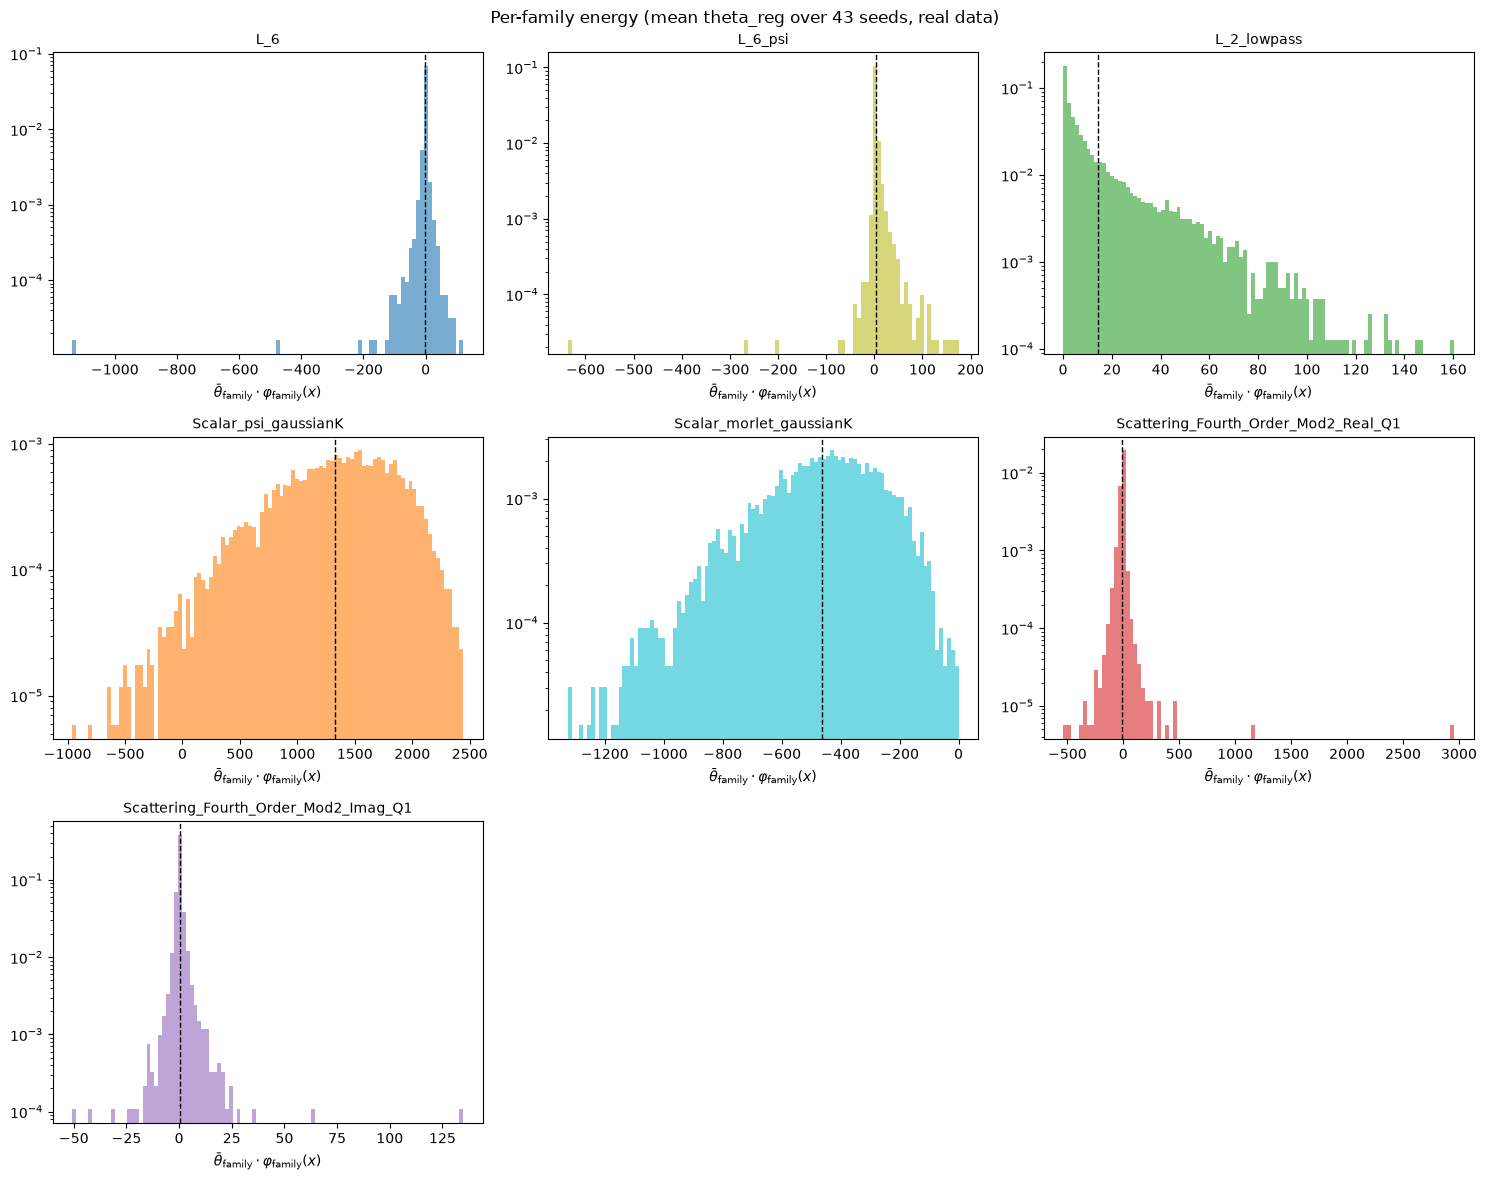

In [9]:
%matplotlib inline
n_families = len(family_energy)
n_cols = 3
n_rows = math.ceil(n_families / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, (name, comp) in enumerate(family_energy.items()):
    ax = axes[i // n_cols][i % n_cols]
    ax.hist(comp, bins=100, density=True, alpha=0.6, color=potential_colors.get(name))
    ax.axvline(comp.mean(), color='k', ls='--', lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(r'$\bar\theta_{\mathrm{family}} \cdot \varphi_{\mathrm{family}}(x)$')
    ax.set_yscale('log')
for j in range(n_families, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis('off')

fig.suptitle(f'Per-family energy (mean theta_reg over {n_seeds} seeds, real data)')
fig.tight_layout()
plt.show()

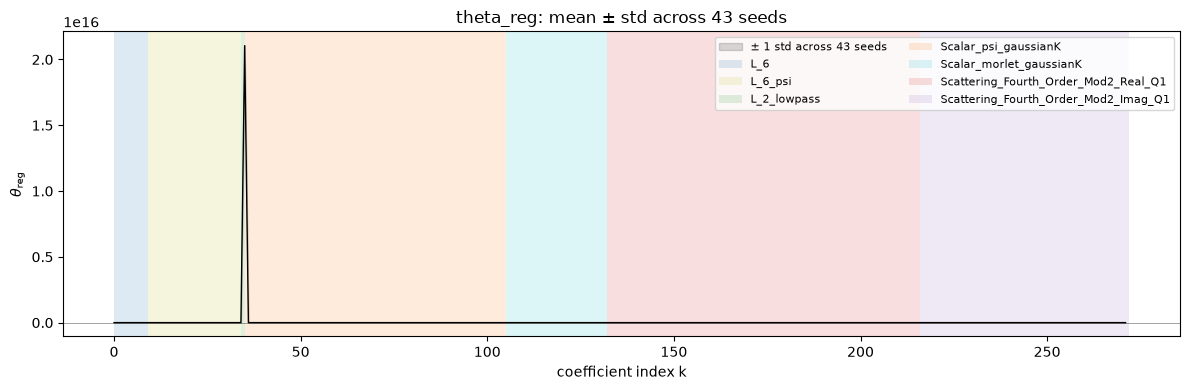

In [10]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12, 4))
k = np.arange(n_features)
ax.plot(k, theta_reg_mean, color='black', lw=1)
ax.fill_between(k, theta_reg_mean - theta_reg_std, theta_reg_mean + theta_reg_std,
                 color='black', alpha=0.15, label=f'\u00b1 1 std across {n_seeds} seeds')

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=potential_colors[name], alpha=0.15, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$\theta_{\mathrm{reg}}$')
ax.set_title(f'theta_reg: mean \u00b1 std across {n_seeds} seeds')
ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

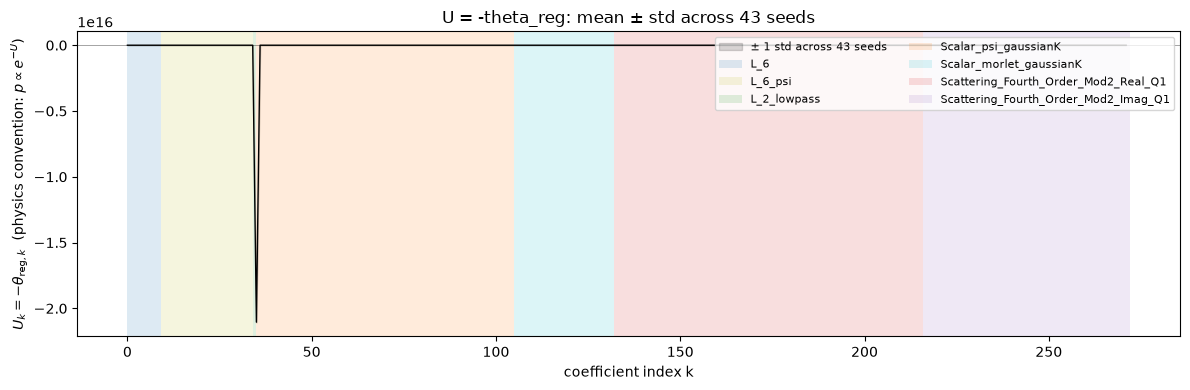

In [11]:
%matplotlib inline
# Physics-convention companion to the plot above: U(x) = -theta.phi(x), so
# p(x) ~ exp(-U(x)) -- same data as theta_reg_mean, sign-flipped, so a confining
# term (higher phi(x) penalized) reads as U > 0 rather than theta_reg < 0.
U_reg_mean = -theta_reg_mean
U_reg_std = theta_reg_std   # std of theta_reg unchanged by an overall sign flip

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(k, U_reg_mean, color='black', lw=1)
ax.fill_between(k, U_reg_mean - U_reg_std, U_reg_mean + U_reg_std,
                 color='black', alpha=0.15, label=f'± 1 std across {n_seeds} seeds')

for name, (a, b) in family_ranges.items():
    ax.axvspan(a, b, color=potential_colors[name], alpha=0.15, lw=0, label=name)

ax.axhline(0, color='black', lw=0.5, alpha=0.5)
ax.set_xlabel('coefficient index k')
ax.set_ylabel(r'$U_k = -\theta_{\mathrm{reg},k}$  (physics convention: $p\propto e^{-U}$)')
ax.set_title(f'U = -theta_reg: mean ± std across {n_seeds} seeds')
ax.legend(loc='upper right', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## log p over the full dataset

$\theta^\top\varphi(x)$ summed over all families = $\log p_\theta(x)$ up to the additive constant $-\log Z(\theta)$.

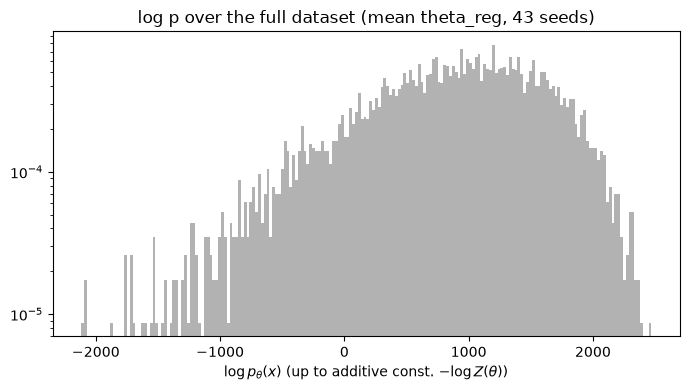

mean=+869.1  std=709.8


In [12]:
plt.figure(figsize=(7, 4))
plt.hist(total_log_p_unnorm, bins=200, density=True, alpha=0.6, color='tab:gray')
plt.yscale('log')
plt.xlabel(r'$\log p_\theta(x)$ (up to additive const. $-\log Z(\theta)$)')
plt.title(f'log p over the full dataset (mean theta_reg, {n_seeds} seeds)')
plt.tight_layout()
plt.show()
print(f"mean={total_log_p_unnorm.mean():+.4g}  std={total_log_p_unnorm.std(ddof=1):.4g}")

## Fisher vs Dirichlet normalisation of theta_reg

$\Sigma = \mathrm{Cov}_{p^*}(\varphi)$ (Fisher, statistical distinguishability) vs $G = \mathbb{E}[\nabla_x\varphi\nabla_x\varphi^\top]$ (Dirichlet, force-field contribution). Both estimated on `x1` using `potentials_ref`; the theta values are always `theta_reg_mean`.

In [13]:
def sample_covariance(phi):
    phi_np = phi.detach().cpu().numpy() if torch.is_tensor(phi) else np.asarray(phi)
    return np.cov(phi_np, rowvar=False, ddof=1)

Sigma_full = sample_covariance(phi_X)
J_full = compute_phi_grad_X(potentials_ref, x1)             # (n1, n_features, T)
G_full = (torch.einsum('ndt,net->de', J_full, J_full) / J_full.shape[0]).cpu().numpy()

Sigma_by_family = {name: Sigma_full[a:b, a:b] for name, (a, b) in family_ranges.items()}
G_by_family = {name: G_full[a:b, a:b] for name, (a, b) in family_ranges.items()}

print(f"{'family':45s} {'dim':>5s} {'cond(Sigma)':>14s} {'cond(G)':>14s}")
for name, (a, b) in family_ranges.items():
    print(f"{name:45s} {b - a:5d} {np.linalg.cond(Sigma_by_family[name]):14.3g} "
          f"{np.linalg.cond(G_by_family[name]):14.3g}")
print(f"{'[full stacked phi]':45s} {n_features:5d} {np.linalg.cond(Sigma_full):14.3g} "
      f"{np.linalg.cond(G_full):14.3g}")

family                                          dim    cond(Sigma)        cond(G)
L_6                                               9       2.94e+12        1.2e+09
L_6_psi                                          25        1.4e+32            inf
L_2_lowpass                                       1              1              1
Scalar_psi_gaussianK                             70       7.07e+26       4.09e+24
Scalar_morlet_gaussianK                          27       5.99e+08            106
Scattering_Fourth_Order_Mod2_Real_Q1             84       1.21e+11       2.03e+08
Scattering_Fourth_Order_Mod2_Imag_Q1             56       4.63e+09       4.46e+06
[full stacked phi]                              272       3.58e+19       1.72e+17


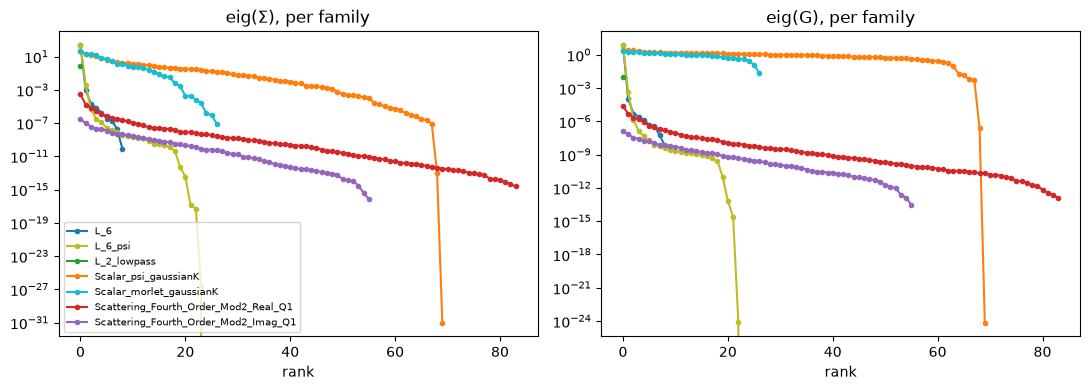

In [14]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in family_ranges:
    color = potential_colors.get(name)
    axes[0].plot(np.sort(np.linalg.eigvalsh(Sigma_by_family[name]))[::-1], marker='o', ms=3, label=name, color=color)
    axes[1].plot(np.sort(np.linalg.eigvalsh(G_by_family[name]))[::-1], marker='o', ms=3, label=name, color=color)
for ax, title in zip(axes, [r'eig($\Sigma$)', 'eig(G)']):
    ax.set_yscale('log'); ax.set_xlabel('rank'); ax.set_title(f'{title}, per family')
axes[0].legend(fontsize=7)
fig.tight_layout()
plt.show()

Raw $|\theta_{\rm reg}|$ and three normalisations, diagonal first (dimensionally safe): $\Sigma_{ii}^{1/2}\theta_i$, $G_{ii}^{1/2}\theta_i$. Full-matrix $\Sigma^{1/2}\theta$ / $G^{1/2}\theta$ only after rescaling every $\varphi_i$ to unit sample sd.

In [15]:
def sym_sqrt(M):
    w, V = np.linalg.eigh((M + M.T) / 2)
    w = np.clip(w, 0, None)
    return V @ np.diag(np.sqrt(w)) @ V.T

diag_sigma = np.diag(Sigma_full)
diag_G = np.diag(G_full)
theta_hat_sigma_diag = np.sqrt(diag_sigma) * theta_reg_mean
theta_hat_G_diag = np.sqrt(diag_G) * theta_reg_mean

sd_phi = np.sqrt(diag_sigma)
inv_sd_phi = np.divide(1.0, sd_phi, out=np.zeros_like(sd_phi), where=sd_phi > 0)
Sigma_tilde = (inv_sd_phi[:, None] * Sigma_full) * inv_sd_phi[None, :]
G_tilde = (inv_sd_phi[:, None] * G_full) * inv_sd_phi[None, :]
theta_tilde = sd_phi * theta_reg_mean
theta_hat_sigma_full = sym_sqrt(Sigma_tilde) @ theta_tilde
theta_hat_G_full = sym_sqrt(G_tilde) @ theta_tilde

norm_summary = pd.DataFrame([
    {
        'family': name, 'dim': b - a,
        'median|theta|': np.median(np.abs(theta_reg_mean[a:b])),
        'median|theta_hat_Sigma_diag|': np.median(np.abs(theta_hat_sigma_diag[a:b])),
        'median|theta_hat_G_diag|': np.median(np.abs(theta_hat_G_diag[a:b])),
        'median|theta_hat_Sigma_full|': np.median(np.abs(theta_hat_sigma_full[a:b])),
        'median|theta_hat_G_full|': np.median(np.abs(theta_hat_G_full[a:b])),
    }
    for name, (a, b) in family_ranges.items()
])
display(norm_summary)

,family,dim,median|theta|,median|theta_hat_Sigma_diag|,median|theta_hat_G_diag|,median|theta_hat_Sigma_full|,median|theta_hat_G_full|
0,L_6,9,1340.734863,3.072188,1.775891,5.177023,1.855152
1,L_6_psi,25,9272.884766,1.438391,0.654126,4.946278,1.853647
2,L_2_lowpass,1,22.417921,20.172087,2.231129,39.677491,4.161459
3,Scalar_psi_gaussianK,70,41.233925,17.713974,41.233921,48.349703,38.194406
4,Scalar_morlet_gaussianK,27,32.589951,19.254209,32.589935,49.502788,28.906425
5,Scattering_Fourth_Order_Mod2_Real_Q1,84,13783.442383,2.105739,1.890363,8.158956,3.561144
6,Scattering_Fourth_Order_Mod2_Imag_Q1,56,14846.523438,0.243483,0.382946,2.606401,0.655334


$\theta^\top\Sigma\theta / \theta^\top G\theta$ is a squared length scale (G carries $\nabla_x$); componentwise $(\Sigma_{ii}/G_{ii})^{1/2}$ is the same thing per coefficient. Checked on $\varphi_4$'s real branch against the $2^{2j}$ scale-locality prediction.

family                                         theta^T Sigma theta / theta^T G theta
L_6                                                                           0.3182
L_6_psi                                                                       0.1572
L_2_lowpass                                                                    81.74
Scalar_psi_gaussianK                                                       7.792e-05
Scalar_morlet_gaussianK                                                     0.001458
Scattering_Fourth_Order_Mod2_Real_Q1                                          0.6818
Scattering_Fourth_Order_Mod2_Imag_Q1                                          0.4564
[full]                                                                     0.0001384


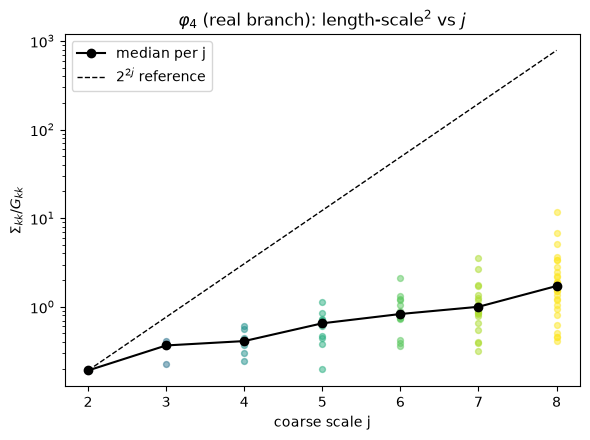

In [16]:
ratio_global = {}
for name, (a, b) in family_ranges.items():
    th = theta_reg_mean[a:b]
    num, den = th @ Sigma_by_family[name] @ th, th @ G_by_family[name] @ th
    ratio_global[name] = num / den if den != 0 else np.nan
ratio_global['[full]'] = (theta_reg_mean @ Sigma_full @ theta_reg_mean) / (theta_reg_mean @ G_full @ theta_reg_mean)

print(f"{'family':45s} {'theta^T Sigma theta / theta^T G theta':>38s}")
for name, r in ratio_global.items():
    print(f"{name:45s} {r:38.4g}")

pot_re = potentials_ref[REAL_KEY]
j_arr, s1_arr, s2_arr = decode_mod2_stq(pot_re, verbose=False)
lag = np.abs(s1_arr - s2_arr)
j_vals_arr = np.array(sorted(set(j_arr.tolist())))
cmap_j = plt.get_cmap('viridis', int(j_vals_arr.max()) + 1)

a_re4, b_re4 = family_ranges[REAL_KEY]
len2_per_k = diag_sigma[a_re4:b_re4] / diag_G[a_re4:b_re4]
med_len2 = np.array([np.median(len2_per_k[j_arr == jv]) for jv in j_vals_arr])

%matplotlib inline
fig, ax = plt.subplots(figsize=(6, 4.5))
for jv in j_vals_arr:
    mask = j_arr == jv
    ax.scatter(np.full(mask.sum(), jv), len2_per_k[mask], color=cmap_j(jv), alpha=0.5, s=18)
ax.plot(j_vals_arr, med_len2, color='black', marker='o', label='median per j')
ax.plot(j_vals_arr, med_len2[0] * 4.0 ** (j_vals_arr - j_vals_arr[0]), 'k--', lw=1, label=r'$2^{2j}$ reference')
ax.set_yscale('log')
ax.set_xlabel('coarse scale j'); ax.set_ylabel(r'$\Sigma_{kk}/G_{kk}$')
ax.set_title(r'$\varphi_4$ (real branch): length-scale$^2$ vs $j$')
ax.legend()
fig.tight_layout()
plt.show()

**Main target:** $\varphi_4$'s normalised couplings vs scale j, log-log, with local power-law slopes. Does the orders-of-magnitude spread in raw $\theta_{\rm reg}$ survive under both metrics, or collapse under one?

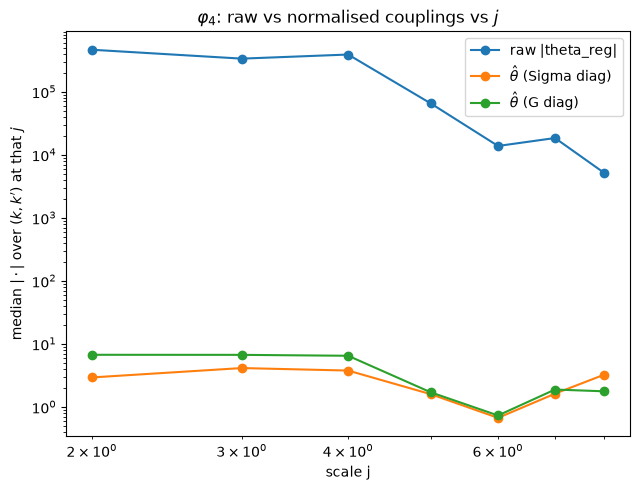

series                             mean local log-log slope
raw |theta_reg|                                      -4.085
$\hat\theta$ (Sigma diag)                             0.477
$\hat\theta$ (G diag)                                -0.848


In [17]:
theta_re4 = theta_reg_mean[a_re4:b_re4]
theta_hat_S4 = np.sqrt(diag_sigma[a_re4:b_re4]) * theta_re4
theta_hat_G4 = np.sqrt(diag_G[a_re4:b_re4]) * theta_re4

def median_abs_by(index_arr, vals, bins):
    return np.array([np.median(np.abs(vals[index_arr == b])) for b in bins])

series4 = {
    'raw |theta_reg|': median_abs_by(j_arr, theta_re4, j_vals_arr),
    r'$\hat\theta$ (Sigma diag)': median_abs_by(j_arr, theta_hat_S4, j_vals_arr),
    r'$\hat\theta$ (G diag)': median_abs_by(j_arr, theta_hat_G4, j_vals_arr),
}
j_pos = j_vals_arr > 0

%matplotlib inline
fig, ax = plt.subplots(figsize=(6.5, 5))
for label, vals in series4.items():
    ax.loglog(j_vals_arr[j_pos], vals[j_pos], marker='o', label=label)
ax.set_xlabel('scale j'); ax.set_ylabel(r"median $|\cdot|$ over $(k,k')$ at that $j$")
ax.set_title(r'$\varphi_4$: raw vs normalised couplings vs $j$')
ax.legend()
fig.tight_layout()
plt.show()

print(f"{'series':30s} {'mean local log-log slope':>28s}")
for label, vals in series4.items():
    log_j, log_v = np.log(j_vals_arr[j_pos]), np.log(np.clip(vals[j_pos], 1e-300, None))
    slopes = np.diff(log_v) / np.diff(log_j)
    print(f"{label:30s} {np.nanmean(slopes):28.3f}")

Same question against the scale lag $|k-k'|$ instead of $j$ -- $\varphi_4$ couples pairs of scales, so lag is the natural $(k,k')$ summary.

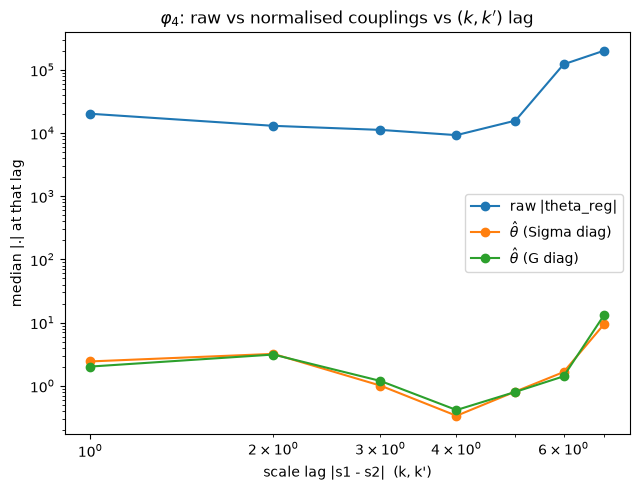

In [18]:
raw_by_var = {
    'raw |theta_reg|': theta_re4,
    r'$\hat\theta$ (Sigma diag)': theta_hat_S4,
    r'$\hat\theta$ (G diag)': theta_hat_G4,
}
lag_vals = np.array(sorted(set(lag.tolist())))

%matplotlib inline
fig, ax = plt.subplots(figsize=(6.5, 5))
for label, vals in raw_by_var.items():
    med_by_lag = np.array([np.median(np.abs(vals[lag == lv])) for lv in lag_vals])
    ax.loglog(lag_vals[lag_vals > 0], med_by_lag[lag_vals > 0], marker='o', label=label)
ax.set_xlabel("scale lag |s1 - s2|  (k, k')")
ax.set_ylabel("median |.| at that lag")
ax.set_title(r"$\varphi_4$: raw vs normalised couplings vs $(k,k')$ lag")
ax.legend()
fig.tight_layout()
plt.show()

**Estimation caveat, checked not assumed:** $\Sigma$ needs $\sim$8th-order moments of the field ($\varphi_4$ is quartic, $\Sigma=\mathrm{Cov}(\varphi_4)$); G needs only $\sim$6th ($\nabla\varphi_4$ is cubic). Checked by re-estimating both from growing subsamples of `x1` (log-x axis), on $\varphi_4$'s smallest/median/largest-j diagonal entries.

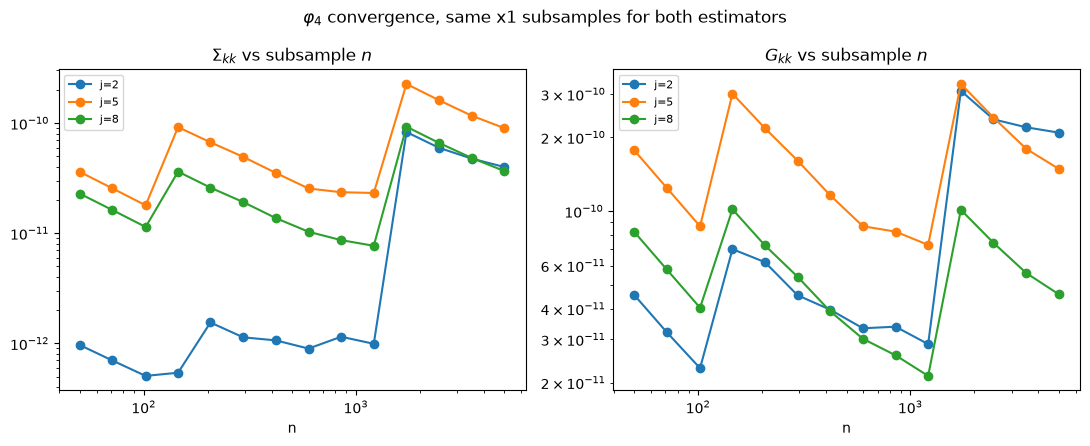

In [19]:
track_idx = {
    f'j={j_vals_arr.min()}': int(np.where(j_arr == j_vals_arr.min())[0][0]),
    f'j={j_vals_arr[len(j_vals_arr)//2]}': int(np.where(j_arr == j_vals_arr[len(j_vals_arr)//2])[0][0]),
    f'j={j_vals_arr.max()}': int(np.where(j_arr == j_vals_arr.max())[0][0]),
}

phi4_re_np = phi_X[:, a_re4:b_re4]
J4 = J_full[:, a_re4:b_re4, :]

n_grid = np.unique(np.round(np.geomspace(50, x1.shape[0], 14)).astype(int))
Sigma_conv = {name: [] for name in track_idx}
G_conv = {name: [] for name in track_idx}
for n in n_grid:
    cov_n = np.cov(phi4_re_np[:n], rowvar=False, ddof=1)
    G_n = (torch.einsum('ndt,net->de', J4[:n], J4[:n]) / n).cpu().numpy()
    for name, idx in track_idx.items():
        Sigma_conv[name].append(cov_n[idx, idx])
        G_conv[name].append(G_n[idx, idx])

%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name in track_idx:
    axes[0].plot(n_grid, Sigma_conv[name], marker='o', label=name)
    axes[1].plot(n_grid, G_conv[name], marker='o', label=name)
for ax, title in zip(axes, [r'$\Sigma_{kk}$ vs subsample $n$', r'$G_{kk}$ vs subsample $n$']):
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('n'); ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle(r'$\varphi_4$ convergence, same x1 subsamples for both estimators')
fig.tight_layout()
plt.show()